In [1]:
import distutils.spawn
from functools import partial

import jax
from jax import numpy as jnp
from jax import random
from matplotlib import pyplot as plt
from matplotlib import rc
import pandas as pd
import seaborn as sns

In [2]:
sns.set(font_scale=2.0)
if distutils.spawn.find_executable("latex"):
    rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
    rc("text", usetex=True)

/var/folders/5t/1858x_sn3kz5tw252hv5nw3w0000gn/T/ipykernel_53507/3010401971.py:2: DeprecationWarning: Use shutil.which instead of find_executable
  if distutils.spawn.find_executable("latex"):


In [3]:
# x is a d-dim vector
def layer_norm_single_token(x):
    mu = jnp.mean(x)
    sigma = jnp.std(x)
    return (x-mu)/(sigma+1e-5)

In [4]:
layer_norm = jax.vmap(layer_norm_single_token, in_axes=0)

In [5]:
def compute_attention_output(X, single_W_k, single_W_q, single_W_v):
    attention_matrix = (X @ single_W_k.T) @ (single_W_q @ X.T) / jnp.sqrt(r)   # LxL
    return jax.nn.softmax(attention_matrix, axis=1) @ X @ single_W_v

In [6]:
compute_multi_head_attention_output = jax.vmap(compute_attention_output, in_axes=[None, 0, 0, 0], out_axes=1)

In [7]:
# X is a Lxd matrix, W_k, W_q are hxrxd, W_v is hxdxr, W_O is dxd
def multi_head_attention_layer(X, W_k, W_q, W_v, W_O):
    h, d, r = W_v.shape
    L = X.shape[0]
    assert h * r == d
    normed_X = layer_norm(X)
    attention_output = compute_multi_head_attention_output(normed_X, W_k, W_q, W_v)  # Lxhxr
    return X + jnp.reshape(attention_output, shape=(L, d)) @ W_O   # Lxd

In [8]:
# X is a d-dim vector, W_1 is mxd, W_2 is dxm
def ff_layer_single_token(x, W_1, W_2, b_1, b_2):
    return x + W_2 @ jax.nn.relu(W_1@x + b_1) + b_2

In [9]:
ff_layer = jax.vmap(ff_layer_single_token, in_axes=[0, None, None, None, None])

In [10]:
# keep only the first coordinate of X
def linear_projector(X, theta):
    return theta @ X[0]

In [11]:
def attention_ff_proj(X, params):
    register, W_k, W_q, W_v, W_O, W_1, W_2, b_1, b_2, theta = params
    X_with_register = jnp.concatenate([register.reshape(1,-1), X], axis=0)
    after_attention = multi_head_attention_layer(X_with_register, W_k, W_q, W_v, W_O)
    after_ff = ff_layer(after_attention, W_1, W_2, b_1, b_2)
    return linear_projector(after_ff, theta)

In [12]:
batched_attention_proj = jax.vmap(attention_ff_proj, in_axes=[0, None], out_axes=0)

def risk_fn(X, y, params):
    """Loss with mean-squared error for our problem."""
    return jnp.mean((batched_attention_proj(X, params) - y) ** 2)

grad_fn = jax.value_and_grad(risk_fn, argnums=2)

def init_star(d, key):
    """Initialization of k* and v* on the sphere."""
    subkeys = random.split(key, 2)
    k_star = random.normal(subkeys[0], shape=(d,))
    k_star = k_star / jnp.linalg.norm(k_star)
    v_star = random.normal(subkeys[1], shape=(d,))
    v_star = v_star - k_star @ v_star * k_star
    v_star = v_star / jnp.linalg.norm(v_star)
    return k_star, v_star

def generate_params(r, d, h, m, key):
    # Xavier initialization N(0, 2/(d_in + d_out))
    subkeys = random.split(key, 7)
    register = random.normal(subkeys[6], shape=(d,)) * jnp.sqrt(1/d)
    W_k = random.normal(subkeys[0], shape=(h,r,d)) * jnp.sqrt(2/(r+d))
    W_q = jnp.zeros(shape=(h,r,d))
    W_v = random.normal(subkeys[2], shape=(h,d,r)) * jnp.sqrt(2/(r+d))
    W_O = random.normal(subkeys[2], shape=(d,d)) * jnp.sqrt(1/d)
    W_1 = random.normal(subkeys[3], shape=(m,d)) * jnp.sqrt(2/(m+d))
    W_2 = random.normal(subkeys[4], shape=(d,m)) * jnp.sqrt(2/(m+d))
    b_1 = jnp.zeros(shape=(m,))
    b_2 = jnp.zeros(shape=(d,))
    theta = random.normal(subkeys[5], shape=(d,)) / d
    return register, W_k, W_q, W_v, W_O, W_1, W_2, b_1, b_2, theta

@partial(jax.jit, static_argnames=["batch_size", "d", "L"])
def generate_batch(list_k_star, list_v_star, batch_size, d, L, eps, gamma, key):
    """Generates one batch of data of the single-location regression distribution."""
    subkeys = random.split(key, 3)
    X_directions = []
    nb_directions = len(list_k_star)
    for k_star in list_k_star:
        X_directions.append(jax.random.multivariate_normal(
            subkeys[0],
            jnp.sqrt(d / 2) * k_star,
            gamma**2 * jnp.eye(d),
            shape=(batch_size, 1),
        ))
    X_directions = jnp.concatenate(X_directions, axis=1)
    other_X_i = jax.random.normal(subkeys[1], shape=(batch_size, L - nb_directions, d))
    xi = eps * jax.random.normal(subkeys[2], shape=(batch_size,))
    all_v_stars = jnp.vstack(list_v_star)
    y = jnp.einsum('ijk,jk->i', X_directions, all_v_stars) + xi
    return jnp.concatenate([X_directions, other_X_i], axis=1), y

@partial(jax.jit, static_argnames=["batch_size", "d", "L"])
def sgd_step(params, list_k_star, list_v_star, d, L, gamma, alpha, batch_size, eps, key):
    """One step of SGD."""
    X, y = generate_batch(list_k_star, list_v_star, batch_size, d, L, eps, gamma, key)
    risk, grad = grad_fn(X, y, params)
    register = params[0]
    params_except_register = jax.tree.map(lambda x,y: x - alpha * y, params[1:], grad[1:])
    return risk, (register,) + params_except_register, grad

In [13]:
L = 10
d = 80
h = 2
nb_data_directions = 2
assert float(int(d/h)) == d/h
r = int(d / h)
m = 200
eps = 0.1
gamma = float(jnp.sqrt(0.5))
alpha = 2e-2
batch_size = 128
test_batch_size = 1000
n_steps = 10_000
log_every = 100
n_runs = 10
key = random.key(0)

logs = {
    "Run": [],
    "Step": [],
    "Excess risk": [],
    "Kappa1": [],
    "Kappa2": [],
    "Nu1": [],
    "Nu2": [],
}

run_subkeys = random.split(key, n_runs)
for run in range(n_runs):
    print("Run {}/{}".format(run+1, n_runs))
    key, subkey, subkey2, subkey3 = random.split(run_subkeys[run], 4)
    params = generate_params(r, d, h, m, subkey)
    list_k_star, list_v_star = [], []
    subsubkeys = random.split(subkey2, nb_data_directions)
    for i in range(nb_data_directions):
        k_star, v_star = init_star(d, subsubkeys[i])
        list_k_star.append(k_star)
        list_v_star.append(v_star)
    test_X, test_y = generate_batch(list_k_star, list_v_star, test_batch_size, d, L, eps, gamma, subkey3)
    list_kappa_11, list_kappa_12, list_kappa_21, list_kappa_22, list_nu_11, list_nu_12, list_nu_21, list_nu_22 = [], [], [], [], [], [], [], []

    keys_sgd = random.split(key, n_steps)
    for step in range(n_steps):
        risk, params, grad = sgd_step(params, list_k_star, list_v_star, d, L, gamma, alpha, batch_size, eps, keys_sgd[step])

        if (step + 1) % log_every == 1:
            logs["Run"].append(run)
            logs["Step"].append(step + 1)
            test_risk = risk_fn(test_X, test_y, params)
            logs["Excess risk"].append(float(test_risk - eps**2))

            register, W_k, W_q, W_v, W_O, W_1, W_2, b_1, b_2, theta = params
            _, _, vt_q = jnp.linalg.svd(W_q[0])
            list_kappa_11.append(float(jnp.abs(vt_q[0] @ list_k_star[0])))
            list_kappa_12.append(float(jnp.abs(vt_q[0] @ list_k_star[1])))
            _, _, vt_q = jnp.linalg.svd(W_q[1])
            list_kappa_21.append(float(jnp.abs(vt_q[0] @ list_k_star[0])))
            list_kappa_22.append(float(jnp.abs(vt_q[0] @ list_k_star[1])))

            head = 0
            x = theta @ (jnp.eye(d,) + W_2 @ W_1) @ (W_v[head] @ W_O[head*r:(head+1)*r]).T
            list_nu_11.append(float((x / jnp.linalg.norm(x)) @ list_v_star[0]))
            list_nu_12.append(float((x / jnp.linalg.norm(x)) @ list_v_star[1]))
            head = 1
            x = theta @ (jnp.eye(d,) + W_2 @ W_1) @ (W_v[head] @ W_O[head*r:(head+1)*r]).T
            list_nu_21.append(float((x / jnp.linalg.norm(x)) @ list_v_star[0]))
            list_nu_22.append(float((x / jnp.linalg.norm(x)) @ list_v_star[1]))

        if (step + 1) % 1000 == 0:
            print("Step {}/{}".format(step+1, n_steps))

    print(list_kappa_11[-1])
    print(list_kappa_12[-1])
    print(list_kappa_21[-1])
    print(list_kappa_22[-1])
    if list_kappa_11[-1] > list_kappa_12[-1]:
        logs["Kappa1"].extend(list_kappa_11)
        logs["Kappa2"].extend(list_kappa_22)
        logs["Nu1"].extend(list_nu_11)
        logs["Nu2"].extend(list_nu_22)
    else:
        logs["Kappa1"].extend(list_kappa_21)
        logs["Kappa2"].extend(list_kappa_12)
        logs["Nu1"].extend(list_nu_21)
        logs["Nu2"].extend(list_nu_12)
    
    print()

Run 1/10
Step 1000/10000
Step 2000/10000
Step 3000/10000
Step 4000/10000
Step 5000/10000
Step 6000/10000
Step 7000/10000
Step 8000/10000
Step 9000/10000
Step 10000/10000
0.9659146070480347
0.32907894253730774
0.7930362820625305
0.7471031546592712

Run 2/10
Step 1000/10000
Step 2000/10000
Step 3000/10000
Step 4000/10000
Step 5000/10000
Step 6000/10000
Step 7000/10000
Step 8000/10000
Step 9000/10000
Step 10000/10000
0.7367873787879944
0.7281736135482788
0.5080698132514954
0.8625034093856812

Run 3/10
Step 1000/10000
Step 2000/10000
Step 3000/10000
Step 4000/10000
Step 5000/10000
Step 6000/10000
Step 7000/10000
Step 8000/10000
Step 9000/10000
Step 10000/10000
0.245935320854187
0.9451683163642883
0.8170254230499268
0.5589680671691895

Run 4/10
Step 1000/10000
Step 2000/10000
Step 3000/10000
Step 4000/10000
Step 5000/10000
Step 6000/10000
Step 7000/10000
Step 8000/10000
Step 9000/10000
Step 10000/10000
0.6692841053009033
0.7274284362792969
0.7986310124397278
0.5666179060935974

Run 5/10
Ste

In [14]:
df = pd.DataFrame(logs)

In [15]:
df[-5:]

,Run,Step,Excess risk,Kappa1,Kappa2,Nu1,Nu2
995,9,9501,0.014838,0.878941,0.866838,0.612433,0.650802
996,9,9601,0.014519,0.879164,0.867217,0.614146,0.651024
997,9,9701,0.014437,0.879421,0.867683,0.613892,0.655122
998,9,9801,0.014336,0.879819,0.868326,0.613180,0.655757
999,9,9901,0.014869,0.880046,0.868500,0.614886,0.654472


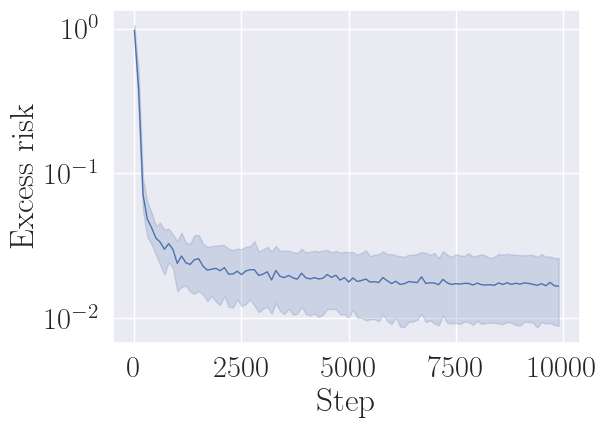

In [16]:
sns.lineplot(
    df,
    x="Step",
    y="Excess risk",
    linewidth=1.0,
)
plt.tight_layout()
#plt.ylim([-0.1, 6.1])
plt.yscale('log')
plt.savefig("figures/excess_risk_transformer_multihead.pdf", bbox_inches="tight")
plt.show()

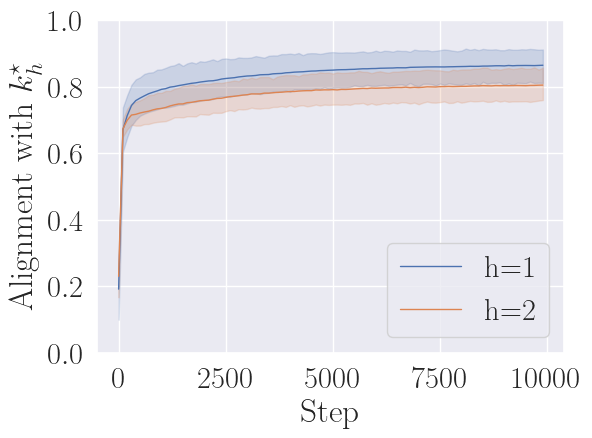

In [17]:
sns.lineplot(df, x="Step", y="Kappa1", linewidth=1.0, label="h=1")
sns.lineplot(df, x="Step", y="Kappa2", linewidth=1.0, label="h=2")
plt.tight_layout()
plt.ylim([0,1])
plt.ylabel(r"Alignment with $k_h^\star$")
plt.legend()
plt.savefig("figures/alignment_k_transformer_multihead.pdf", bbox_inches="tight")
plt.show()

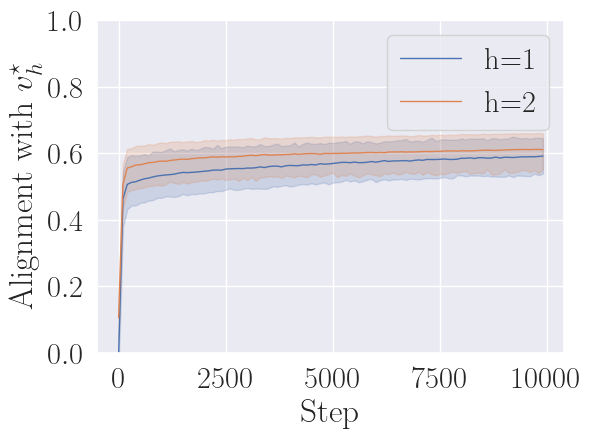

In [18]:
sns.lineplot(df, x="Step", y="Nu1", linewidth=1.0, label="h=1")
sns.lineplot(df, x="Step", y="Nu2", linewidth=1.0, label="h=2")
plt.tight_layout()
plt.ylim([0,1])
plt.ylabel(r"Alignment with $v_h^\star$")
plt.legend()
plt.savefig("figures/alignment_v_transformer_multihead.pdf", bbox_inches="tight")
plt.show()